In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
n_samples = 200
data = pd.read_csv("Advertising.csv")
data.head()
df = pd.DataFrame(data)

In [9]:
# 3. Separate independent features (X) and target variable (y)
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

In [10]:
# 4. Split data into training (80%) and testing (20%) sets
# Note: For small samples like 5 rows, test_size=0.2 will throw an error. 
# This configuration assumes you are running it on your full dataset.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# 5. Initialize and fit the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)
# 6. Predict sales using the test dataset
y_pred = model.predict(X_test)

In [12]:
# --- Display Results & Evaluation Metrics ---
print("--- Model Coefficients ---")
print(f"Intercept (Baseline Sales): {model.intercept_:.4f}")
for feature, coef in zip(X.columns, model.coef_):
    print(f"Coefficient for {feature}: {coef:.4f}")

print("\n--- Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"R-squared Score (R²): {r2_score(y_test, y_pred):.4f}")

--- Model Coefficients ---
Intercept (Baseline Sales): 2.9791
Coefficient for TV: 0.0447
Coefficient for radio: 0.1892
Coefficient for newspaper: 0.0028

--- Evaluation Metrics ---
Mean Squared Error (MSE): 3.1741
R-squared Score (R²): 0.8994


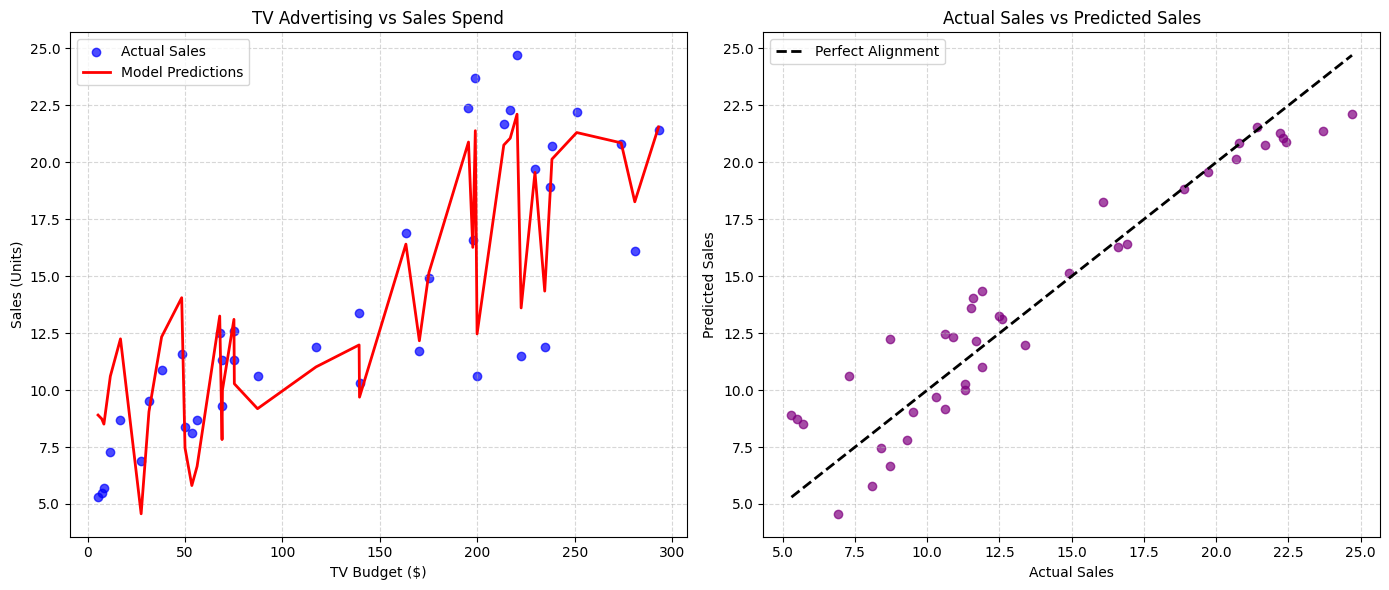

In [13]:
# --- Visualization Section ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Main Driver (TV) vs Sales
ax1.scatter(X_test['TV'], y_test, color='blue', alpha=0.7, label='Actual Sales')
sort_idx = np.argsort(X_test['TV'])
ax1.plot(X_test['TV'].iloc[sort_idx], y_pred[sort_idx], color='red', linewidth=2, label='Model Predictions')
ax1.set_title('TV Advertising vs Sales Spend')
ax1.set_xlabel('TV Budget ($)')
ax1.set_ylabel('Sales (Units)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)
# Plot 2: Accuracy Assessment
ax2.scatter(y_test, y_pred, color='purple', alpha=0.7)
ideal_line = np.linspace(min(y_test), max(y_test), 100)
ax2.plot(ideal_line, ideal_line, color='black', linestyle='--', linewidth=2, label='Perfect Alignment')
ax2.set_title('Actual Sales vs Predicted Sales')
ax2.set_xlabel('Actual Sales')
ax2.set_ylabel('Predicted Sales')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [20]:
# Fix: Pass only the 2 columns you want to plot to X
X = df[['TV', 'radio']]  # 2 features
y = df['sales']

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


/home/govardhanks/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


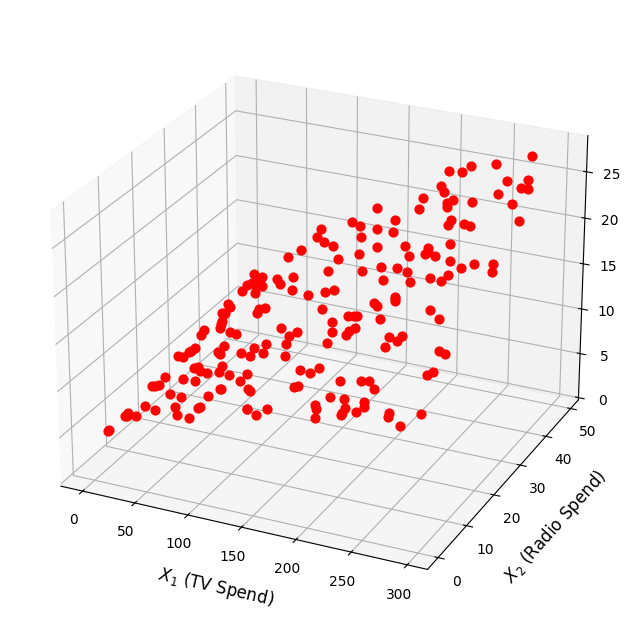

In [27]:
# 4. Initialize a 3D figure axis environment
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 5. Plot the actual observations as red sphere markers
ax.scatter(df['TV'], df['radio'], df['sales'], color='red', s=40, depthshade=False, zorder=5, label='Observations')

# 6. Generate an evenly spaced grid mesh for the regression plane surface
tv_range = np.linspace(df['TV'].min(), df['TV'].max(), 20)
radio_range = np.linspace(df['radio'].min(), df['radio'].max(), 20)
TV_mesh, RADIO_mesh = np.meshgrid(tv_range, radio_range)

# Flatten grid arrays to calculate continuous model surface coordinate predictions
grid_coordinates = np.c_[TV_mesh.ravel(), RADIO_mesh.ravel()]
sales_pred_mesh = model.predict(grid_coordinates).reshape(TV_mesh.shape)
# 3. Apply explicit structural axis labels to match the figure pattern
ax.set_xlabel('$X_1$ (TV Spend)', fontsize=12, labelpad=10)
ax.set_ylabel('$X_2$ (Radio Spend)', fontsize=12, labelpad=10)
# Fix: Force the Z-axis label explicitly onto your 3D axis object
ax.set_zlabel('$Y$ (Sales)', fontsize=12, labelpad=10)

# Optional: Adjust the camera viewing rotation if the label clips off-screen
ax.view_init(elev=25, azim=-65)

In [22]:
# 7. Render the translucent colored regression surface plane
surf = ax.plot_surface(
    TV_mesh, RADIO_mesh, sales_pred_mesh, 
    cmap='viridis', alpha=0.6, linewidth=0, antialiased=True, zorder=1
)

In [23]:
# 8. Draw vertical black drop lines representing residuals for each data point
y_pred_points = model.predict(X)
for i in range(len(df)):
    # Connect observed real dot coordinate to the corresponding point on the model plane
    ax.plot(
        [df['TV'].iloc[i], df['TV'].iloc[i]],
        [df['radio'].iloc[i], df['radio'].iloc[i]],
        [df['sales'].iloc[i], y_pred_points[i]],
        color='black', linestyle='-', linewidth=0.8, alpha=0.7, zorder=2
    )

In [24]:
# 9. Format labels and camera perspective angle
ax.set_xlabel('TV Spend ($)', fontsize=11, labelpad=10)
ax.set_ylabel('Radio Spend ($)', fontsize=11, labelpad=10)
ax.set_zlabel('Sales (Units)', fontsize=11, labelpad=10)
ax.set_title('Multiple Linear Regression Surface Plane', fontsize=14, pad=20)

# Adjust viewing angle to mirror the book figure perspective
ax.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>